In [71]:
# import libraries

import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets as ml_data
from sklearn.decomposition import PCA

# Power Method
## Generating a Matrix with a Singular Value Gap

In [4]:
np.random.seed(0)
n, m = 100, 50

# Generate U and V from a random matrix SVD
A_rand = np.random.randn(n, m)
U, _, Vt = np.linalg.svd(A_rand, full_matrices=False)

# Define singular values with a gap
s = np.linspace(10, 1, m)
s[1:] *= 0.1 # compress all except the top singular value
S = np.diag(s)

# construct the matrix A with matrix multiplication
A = U @ S @ Vt

Text(0.5, 0, 'Singular Values')

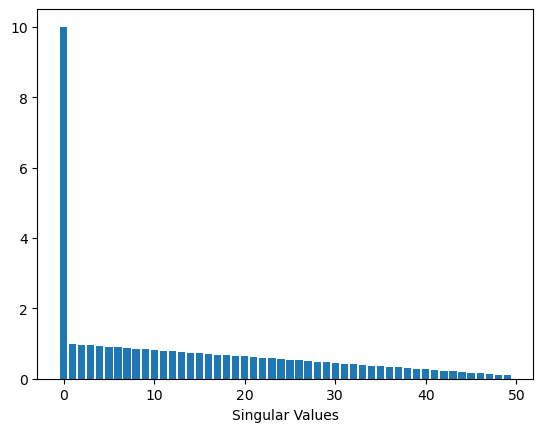

In [11]:
plt.bar(range(m), s)
plt.xlabel('Singular Values')

We choose a large spectral gap because this help ensures that the power method will converge quickly and accurately. The rate at which the power method converges is determined by the gap between the first and second singular values:
$$ \frac{\sigma_{2}}{\sigma_{1}} $$
The error in step $k$ of our algorithm is
$$ O \left(\left(\frac{\sigma_{2}}{\sigma_{1}}\right)^{2k}\right) $$
Thus, a smaller ratio means faster convergence.

## Implementing the Power Method
To find the dominant right sigular vector, our function will iteratively compute
$$ v_{k+1}' = A^T A v_{k} $$
and then normalize
$$ v_{k + 1} = \frac{v_{k+1}'}{||v_{k+1}'||} $$
When the initial vector has a nonzero component in the direction of the right top singular vector, we expect the algorithm to converge to the dominant right singular vector (ie the vecotr corresponding to the largest singular value). This is because in each step the component in this direction gets larger, while normalization ensures all the other components get smaller (and nothing blows up).

In [37]:
def normalize(vector):
    return vector / np.linalg.norm(vector)

def power_method(A, v0, num_iter):
    vs = []
    v = v0
    B = A.T @ A
    for _ in range(num_iter):
        v = B @ v
        v = normalize(v)
        vs.append(v)
    return vs

## Initializations
We will initialize two unit vectors:
1. A random vector from the standard normal distibution
2. A vector orthogonal to the leading right singular vector

7.025630077706069e-17


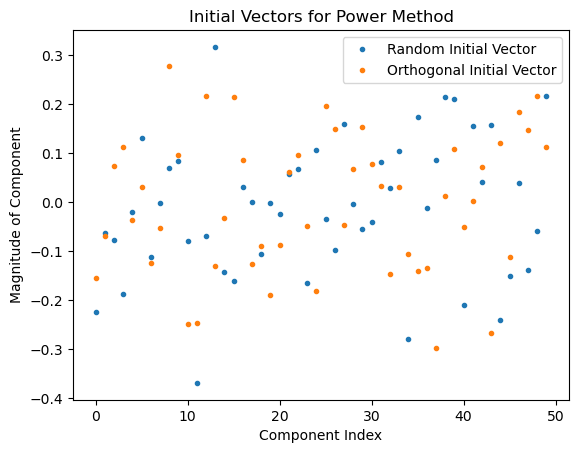

In [28]:
# generate a random initial vector
v_rand = np.random.normal(0, 1, 50)
v_rand = normalize(v_rand)

# generate orthogonal vector
v_orth = Vt[1]

# verify orthogonality
print(np.abs(np.dot(Vt[0], v_orth)))

plt.plot(range(50), v_rand, '.', label='Random Initial Vector')
plt.plot(range(50), v_orth, '.', label='Orthogonal Initial Vector')
plt.legend()
plt.xlabel('Component Index')
plt.ylabel('Magnitude of Component')
plt.title('Initial Vectors for Power Method')
plt.show()

In [38]:
# run the power method for both vectors
power_iter_rand = power_method(A, v_rand, 100)
power_iter_orth = power_method(A, v_orth, 100)

In [50]:
def power_method_error(true_vector, vectors_list):
    errors = []
    for v in vectors_list:
        align = np.abs(np.dot(true_vector, v))
        error = 1 - align
        errors.append(error)
    return errors

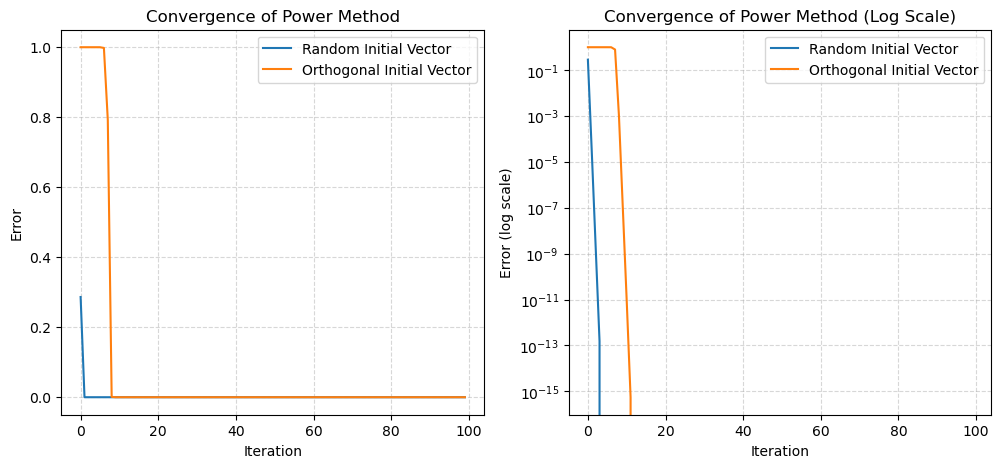

In [52]:
rand_errors = power_method_error(Vt[0], power_iter_rand)
orth_errors = power_method_error(Vt[0], power_iter_orth)

fig, [reg, log] = plt.subplots(1, 2, figsize=(12, 5))

reg.plot(rand_errors, label='Random Initial Vector')
reg.plot(orth_errors, label='Orthogonal Initial Vector')
reg.grid(True, which='both', linestyle='--', alpha=0.5)
reg.set_adjustable('box')
reg.set_xlabel('Iteration')
reg.set_ylabel('Error')
reg.set_title('Convergence of Power Method')
reg.legend()
log.semilogy(rand_errors, label='Random Initial Vector')
log.semilogy(orth_errors, label='Orthogonal Initial Vector')
log.grid(True, which='both', linestyle='--', alpha=0.5)
log.set_xlabel('Iteration')
log.set_ylabel('Error (log scale)')
log.set_title('Convergence of Power Method (Log Scale)')
log.legend()
plt.show()

Text(0.5, 1.0, 'Error of Alignment with Second Singular \n Vector (Orthogonal Initial Vector)')

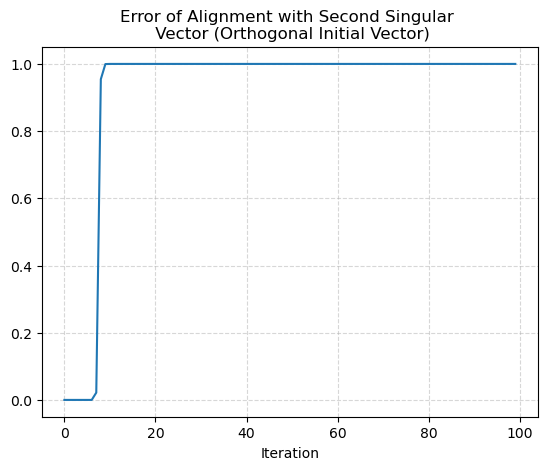

In [55]:
orth_second_error = power_method_error(Vt[1], power_iter_orth)
plt.plot(orth_second_error)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xlabel('Iteration')
plt.title("Error of Alignment with Second Singular \n Vector (Orthogonal Initial Vector)")

The orthogonal inital vector first stays aligned with the second singular vector. However, after approximately ten iterations, it jumps, and eventually stabilizes in the direction of the first singualr vector. This is because the power method grows the small non-zero components in the $v_1$ direction that exists from floating-point arithmetic.

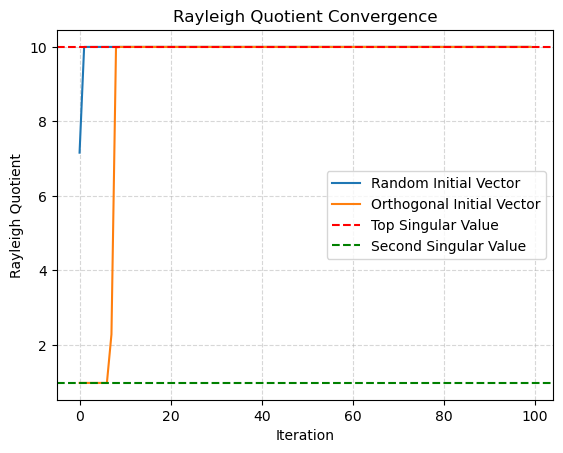

In [58]:
def Rayleigh(A, lst):
    return [np.linalg.norm(A @ v) for v in lst]

Rayleigh_rand = Rayleigh(A, power_iter_rand)
Rayleigh_orth = Rayleigh(A, power_iter_orth)

plt.plot(Rayleigh_rand, label='Random Initial Vector')
plt.plot(Rayleigh_orth, label='Orthogonal Initial Vector')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.axhline(s[0], color='red', linestyle='--', label='Top Singular Value')
plt.axhline(s[1], color='green', linestyle='--', label='Second Singular Value')
plt.xlabel('Iteration')
plt.ylabel('Rayleigh Quotient')
plt.title('Rayleigh Quotient Convergence')
plt.legend()
plt.show()


The Rayleigh quotient is a way of expressing the components

We have
$$ \rho_{k} = ||Av_k||_2 = \sqrt{\left((Av_k)^T Av_{k}\right)} \\
= \sqrt{v_{k}^TA^T A v_{k}}$$
We know from class that $\{v_{i}\}$ are the eigenvectors of $A^T A$, and that the squared singular values are the eigenvalues of $A^T A$. Thus, if we decompose $v_{k}$ into a linear combination of the $\{v_{i}\}'s$, we get
$$ \rho_{k} = \sqrt{v_{k}^TA^T A v_{k}} = \sqrt{(c_1 v_1 + \cdots c_m v_m)^T A^{T} A (c_1 v_1 + \cdots c_m v_m)} \\= \sqrt{(c_1 v_1 + \cdots c_m v_m)^T(c_1 \sigma_1 ^2 v_1 + \cdots c_m \sigma_m^2 v_m)}$$
because $V$ is orthogonal,
$$ = \sqrt{c_{1}^2 \sigma_{1}^2 + \cdots c_{m}^2 \sigma_m^2}$$

Looking at the graph, we see that $\rho_{k}$ is original equal to the second singular value for $v_{\text{orth}}$. This is because we defined the vector such that $c_2 = 1$ and $c_{i} = 0 \forall i \neq 2 \implies \rho_{k} = \sqrt{1\cdot \sigma_{1}^2} = \sigma_1$. Eventually, both initial vectors converge the value of the first singular vector, indicating that $c_1 \rightarrow 1$ and $c_i \rightarrow 0 \forall i \neq 1$.

## Discussion

In our experiment, both the random initial vector and the orthogonal initial vector converged to the first right singular vector. This makes sense for the random vector: this is the intended result of the power method. The random vector is composed on components along all the right singular vectors, and the power method grows the dominant component while shrinking the rest. The orthogonal case is more interesting; thoeretically, $v_{\text{orth}}$ should never converge to $v_{1}$. Since it is an eigenvector of $A^T A$, we expect $= A^T A v_{2} = \sigma^{2}_2 v_{2}$, and thus under normalization we have $v_{k} = v_{2} \forall k$. However, the floating point arithmetic distorts this, and $v_{\text{orth}}$ ultimately converges to $v_{1}$ like the random vector. We do see that $v\text{orth}$ converges more slowly; designing it be be orthogonal to $v_{1}$, although not entirely successful, did lead to smaller components along the $v_{1}$ direction which took larger to grow.

It is also worth noting that both inital vectors converged in less than twenty iterations. This demonstrates that the power method is, in fact, powerful, and accomplishes quick convergence (even in the orthogonal case!).

It is also worth taking away from this the need to think about computer function, and not jusst thoeretical math, in designing algorithms. Rigorous math proofs may not always correctly predict how computers, which are ultimately discrete machines, will function.

# Eigenfaces: PCA and Facial Image Data
 
 We will use the Olivetti Faces dataset to visualize the principal compenents of image data.

In [60]:
# first import the data

from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()
X = faces.data # shape (400, 4096)
images = faces.images # shape (400, 64, 64)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /Users/mayarubenstein/scikit_learn_data


In [66]:
# what data structures are we working with?

print(faces.data.shape)
print(faces.images.shape)
print('faces type', type(faces))
print('faces.data type', type(faces.data))
print('faces.data[2, 3] type', type(faces.data[2, 3]))
print('faces.images type', type(faces.images))
print('faces.images[0, 0, 0] type', type(faces.images[0, 0, 0]))

(400, 4096)
(400, 64, 64)
faces type <class 'sklearn.utils._bunch.Bunch'>
faces.data type <class 'numpy.ndarray'>
faces.data[2, 3] type <class 'numpy.float32'>
faces.images type <class 'numpy.ndarray'>
faces.images[0, 0, 0] type <class 'numpy.float32'>


## PCA Decomposition

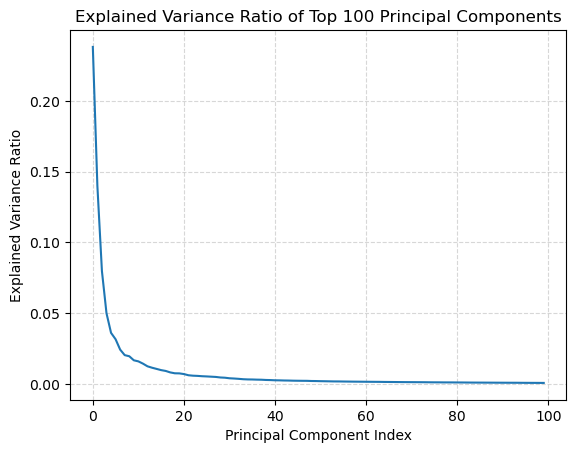

In [73]:
# subtract the mean image to center the data
data_centered = faces.data - np.mean(faces.data, axis=0)

pca = PCA(n_components=100)
data_100d = pca.fit_transform(data_centered)

plt.plot(range(100), pca.explained_variance_ratio_)
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of Top 100 Principal Components')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()


## Visualizing Eigenfaces
Now that we have applied PCA and derived the principle components, we use the analysis to visualize eigenfaces.

<class 'numpy.ndarray'>
(100, 4096)
(10, 4096)


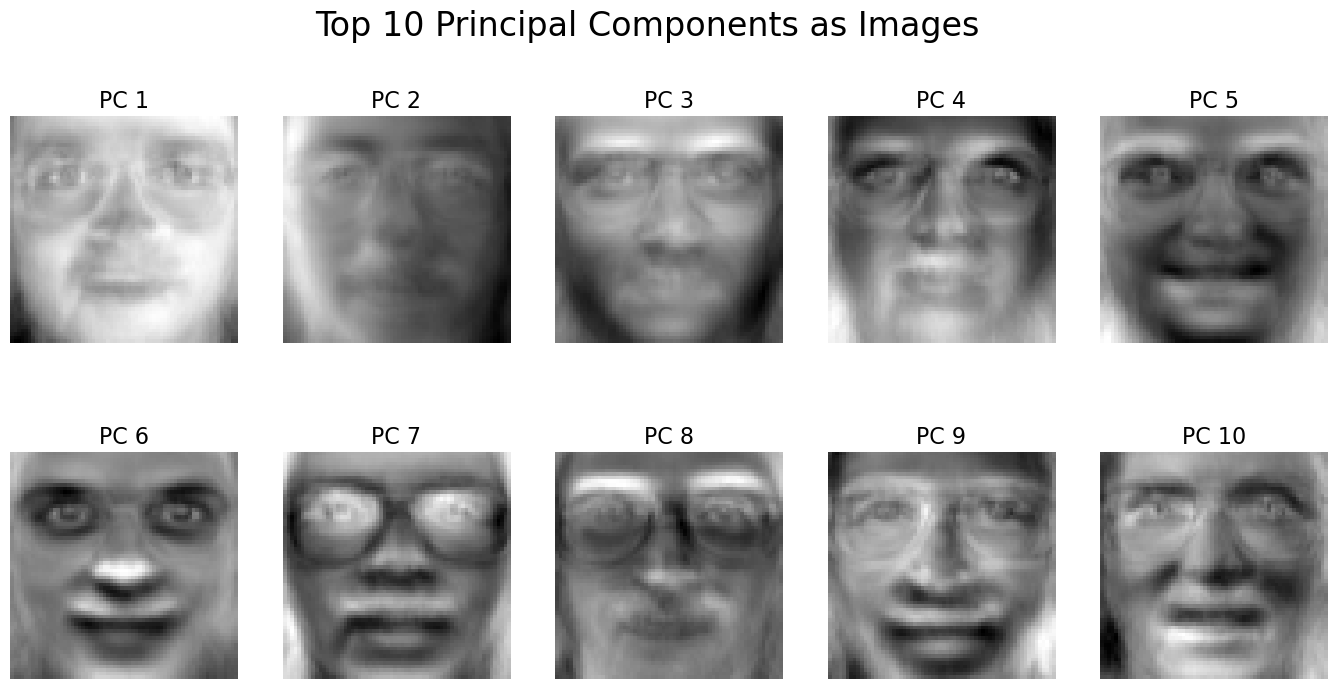

In [85]:
print(type(pca.components_))
print(pca.components_.shape)
ten_components = pca.components_[:10]
print(ten_components.shape)

def unflatten(v):
    return v.reshape(64, 64)

fig, ax = plt.subplots(2, 5, figsize=(17, 8))
for i in range(10):
    row, col = divmod(i, 5)
    ax[row, col].imshow(unflatten(ten_components[i]), cmap='gray')
    ax[row, col].set_title(f'PC {i+1}', fontsize = 16)
    ax[row, col].axis('off')
plt.suptitle('Top 10 Principal Components as Images', fontsize = 24)
plt.show()




Above, we see the 10 principal eigenfaces from the Olivetti Faces dataset. They show the dominant features comprising the facial images. In all of the images, jawline, eyes/eyesockets, a nose, and mouth are discernable. In other words, each eigencomponent has the basic structure of a face, instead of these structures being spread over various components. In the first eigenface, lighting stands out the most: the face is the part of the image with the most light. Other eigenfaces contribute more shadowing. Certain eigenfaces (PC3, PC4, PC7-10) also show the outlines of glasses.